In [53]:
# Cell 1 — Imports
from typing_extensions import TypedDict
from typing import Optional
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [54]:
# Cell 2 — Load env
load_dotenv()


True

In [55]:
# Cell 3 — States
class ParentState(TypedDict):
    question: str     # which language to translate to
    answer_eng: Optional[str]      # no Annotated needed — only one branch runs!
    answer_nep: Optional[str]
    answer_fre: Optional[str]

class NepaliSubgraphState(TypedDict):
    answer_eng: str
    answer_nep: str

class FrenchSubgraphState(TypedDict):
    answer_eng: str
    answer_fre: str

In [56]:
# Cell 4 — LLMs
parent_llm = ChatOpenAI(model='gpt-4o-mini')
subgraph_llm = ChatOpenAI(model='gpt-4o')


In [57]:
# Cell 5 — Node functions
def generate_answer(state: ParentState):
    answer = parent_llm.invoke(f'You are a helpful assistant. Answer clearly.\n\nQuestion: {state["question"]}').content
    return {'answer_eng': answer}

def translate_text(state: NepaliSubgraphState):
    prompt = f'''
Translate the following text to Nepali.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
'''.strip()
    return {'answer_nep': subgraph_llm.invoke(prompt).content}

def translate_text2(state: FrenchSubgraphState):
    prompt = f'''
Translate the following text to French.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
'''.strip()
    return {'answer_fre': subgraph_llm.invoke(prompt).content}

In [58]:
# Cell 6 — Orchestrator / Router
def route_translation(state: ParentState):
    prompt=f'''
From the user question below ,detect which langugae they want the answer in .
Replu with ONLY one word : either 'nepali' or 'french'.
if no langugae is mentioned reply 'nepali' as default.

Question :{state['question']}
'''.strip()
    langugae = parent_llm.invoke(prompt).content.strip().lower()
    return 'translate' if langugae=='nepali' else 'translate2'

In [59]:
def cleanup(state:ParentState):
    return {'answer_eng':None}

In [60]:
# Cell 7 — Build subgraphs
subgraph = StateGraph(NepaliSubgraphState)
subgraph.add_node('translate_text', translate_text)
subgraph.add_edge(START, 'translate_text')
subgraph.add_edge('translate_text', END)
subgraph = subgraph.compile()

subgraph2 = StateGraph(FrenchSubgraphState)
subgraph2.add_node('translate_text2', translate_text2)
subgraph2.add_edge(START, 'translate_text2')
subgraph2.add_edge('translate_text2', END)
subgraph2 = subgraph2.compile()

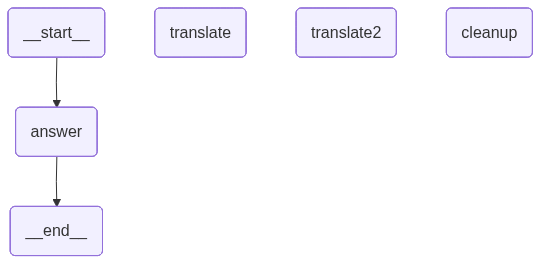

In [61]:
# Cell 8 — Build parent graph
parent_builder = StateGraph(ParentState)

parent_builder.add_node('answer', generate_answer)
parent_builder.add_node('translate', subgraph)
parent_builder.add_node('translate2', subgraph2)
parent_builder.add_node('cleanup',cleanup)

parent_builder.add_edge(START, 'answer')

# orchestrator decides which translation to run
parent_builder.add_conditional_edges('answer', route_translation)

parent_builder.add_edge('translate', 'cleanup')
parent_builder.add_edge('translate2', 'cleanup')
parent_builder.add_edge('cleanup',END)

graph = parent_builder.compile()
graph

In [65]:
graph.invoke({'question': 'What is Nihilism?'})

{'question': 'What is Nihilism?',
 'answer_eng': None,
 'answer_nep': 'निहिलिज्म एक दार्शनिक विश्वास हो जसले जीवनमा नैसर्गिक अर्थ, उद्देश्य, वा मूल्यको अभाव रहेको मान्यता राख्छ। यसले परम्परागत मान्यता र विश्वासलाई, विशेष गरी नैतिकता र धर्ममा, आधारहीन वा असंगत ठान्छ। निहिलिष्टहरूले कुनै पनि वस्तुनिष्ठ सत्यको अवधारणा वा अस्तित्व स्वयम्\u200cमा कुनै महत्व रहेको विचारलाई अस्वीकार गर्न सक्छन्। यस दृष्टिकोणले प्राय: ज्ञान, नैतिकता, र मानव अनुभव प्रति शंका उत्पन्न गर्दछ। निहिलिज्मलाई अस्तित्ववादसँग जोड्न सकिन्छ, किनभने दुवैले अर्थ र अस्तित्वका विषयवस्तुहरूका खोजी गर्छन्, तर निहिलिज्म विशेष गरी अर्थको अभावमा जोड दिन्छ, त्यसको खोजीमा होइन।'}

In [66]:
result = graph.invoke({'question': 'What is Nihilism? Describe in Nepali'})
result.pop('answer_eng')
print(result)

{'question': 'What is Nihilism? Describe in Nepali', 'answer_nep': 'निहिलिज्म (Nihilism) एक दार्शनिक सिद्धान्त हो जसले जीवनको अर्थ, मूल्य र विश्वासहरूको असारता र अस्वीकृति गर्दछ। यसका अनुसार, संसारमा कुनै ठोस अर्थ छैन र कुनै वस्तु वा घटनामा कुनै नैतिक मूल्य छैन। निहिलिज्मले अक्सर जीवनको व्यर्थता र अस्थिरताको भावनालाई उजागर गर्दछ।\n\nयस सिद्धान्तलाई विशेषगरी अस्तित्ववाद (existentialism) संग जोडिन्छ, जहाँ व्यक्तिसँग आफ्नो जीवनको अर्थ निर्माण गर्ने चुनौती हुन्छ। निहिलिज्मले धर्म, नैतिकता र समाजका मूल्यहरूको आलोचना गर्दछ र कहिलेकाहीं यसलाई निराशावादसँग पनि जोडिन्छ।\n\nसारांशमा, निहिलिज्मले जीवनको कुनै स्थायी अर्थ या मूल्यको अभावलाई संकेत गर्दछ।'}
